# Explainable AI - SHAP

This notebook is practice of SHAP library usage on regression problem solution for california_housing_prices.csv dataset.


## Imports & Data load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_df = pd.read_csv('data/california_housing_prices.csv')
raw_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Missing values Handling

In [3]:
from mlpeople.eda.missing import get_null_df, show_filled_numeric_histogram

get_null_df(raw_df)

,column_name,null_count,null_percentage
4,total_bedrooms,207,1.0
0,longitude,0,0.0
1,latitude,0,0.0
2,housing_median_age,0,0.0
3,total_rooms,0,0.0
5,population,0,0.0
6,households,0,0.0
7,median_income,0,0.0
8,median_house_value,0,0.0
9,ocean_proximity,0,0.0


In [4]:
raw_df["total_bedrooms"].describe()

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

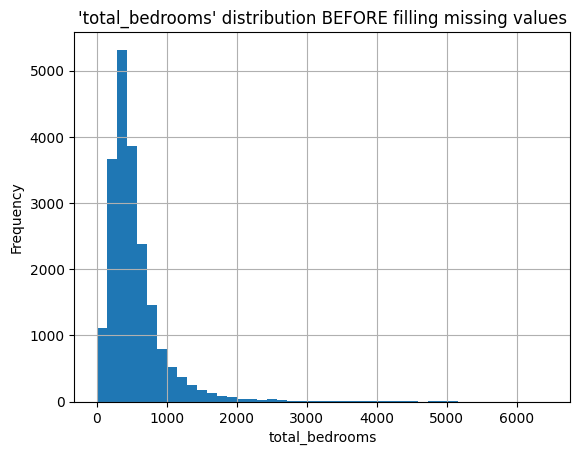

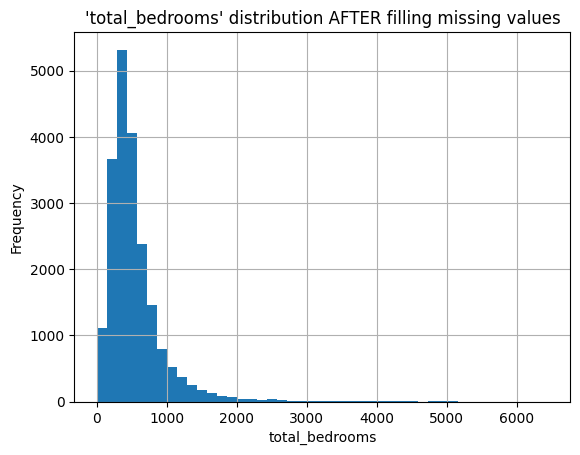

In [5]:
show_filled_numeric_histogram(raw_df, "total_bedrooms", strategy="median", bins=45, show_before=True)

## Train / Test Split

In [6]:
X = raw_df[['longitude','latitude','housing_median_age','total_rooms',
        'total_bedrooms','population','households','median_income']]
y = raw_df['median_house_value']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 0)

## One Decision Tree

In [8]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(max_depth=12, max_leaf_nodes=1200, random_state=0)
model_dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf

In [9]:
y_pred_train = model_dt.predict(X_train)
y_pred = model_dt.predict(X_test)

In [10]:
from sklearn.metrics import root_mean_squared_error

mse_train = root_mean_squared_error(y_train, y_pred_train)
mse = root_mean_squared_error(y_test, y_pred)
mse_train, mse

(36193.76825947759, 63589.38976360228)

### Feature importance from model

In [11]:
importances = model_dt.feature_importances_
feature_importance_dt_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_dt_df = feature_importance_dt_df.sort_values(by='Importance', ascending=False)
feature_importance_dt_df

,Feature,Importance
7,median_income,0.554378
1,latitude,0.167634
0,longitude,0.166736
2,housing_median_age,0.055111
3,total_rooms,0.016291
4,total_bedrooms,0.015593
5,population,0.015005
6,households,0.009251


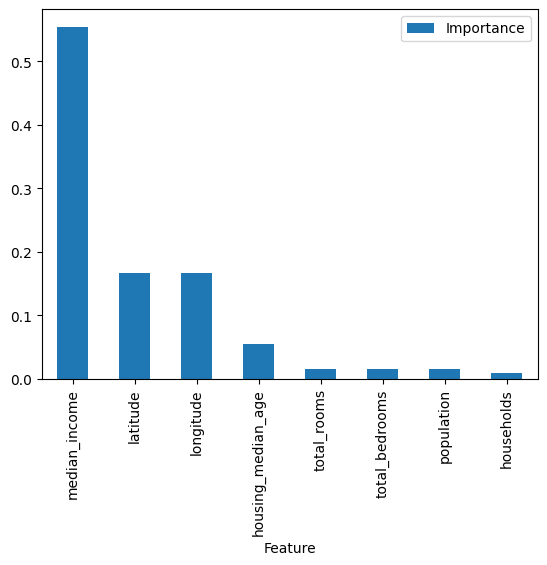

In [12]:
feature_importance_dt_df.set_index('Feature').plot.bar();

## Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(max_depth=10, max_leaf_nodes=250, random_state=0, n_estimators=50)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",250
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [14]:
y_pred_train = model_rf.predict(X_train)
y_pred = model_rf.predict(X_test)

In [15]:
mse_train = root_mean_squared_error(y_train, y_pred_train)
mse = root_mean_squared_error(y_test, y_pred)
mse_train, mse

(45821.77081747261, 55839.694541112345)

### Feature importance from model

In [16]:
importances = model_rf.feature_importances_
feature_importance_rf_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_rf_df = feature_importance_rf_df.sort_values(by='Importance', ascending=False)
feature_importance_rf_df

,Feature,Importance
7,median_income,0.600413
0,longitude,0.154529
1,latitude,0.143540
2,housing_median_age,0.057921
4,total_bedrooms,0.014770
5,population,0.014122
3,total_rooms,0.007488
6,households,0.007217


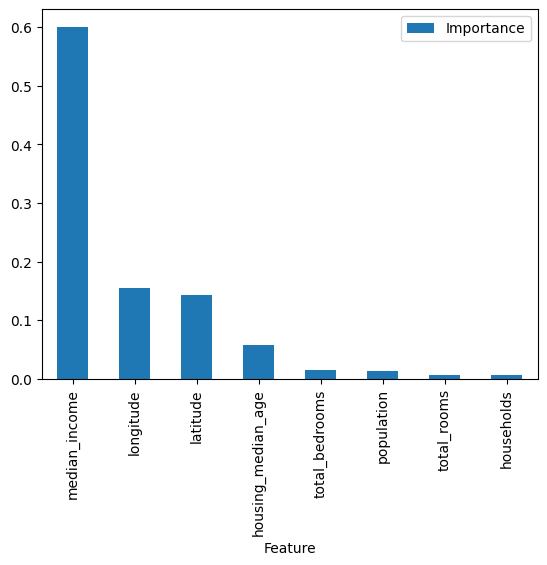

In [17]:
feature_importance_rf_df.set_index('Feature').plot.bar();

## SHAP

### SHAP Explanation Force Plots

/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


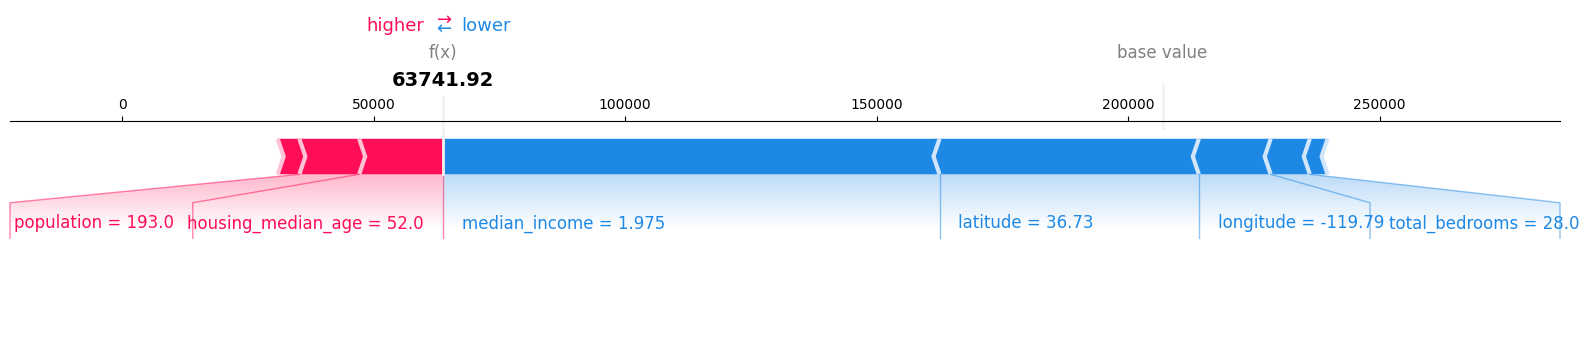

In [18]:
# import shap
import shap

# create an object to explain the model predictions using SHAP
explainer_dt = shap.TreeExplainer(model_dt)
shap_values_dt = explainer_dt.shap_values(X_train)

# visualize the explanation of the first prediction
# shap.initjs() - don't need it since use matplotlib=True to have a static image that is visible on github
shap.force_plot(explainer_dt.expected_value, shap_values_dt[0,:], X_train.iloc[0,:], matplotlib=True)

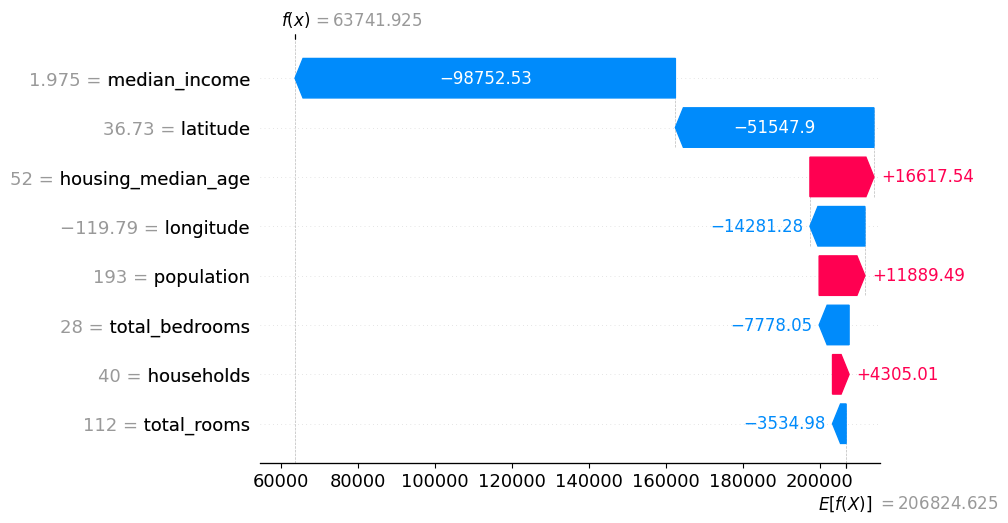

In [19]:
# alternative plot (dispay same info differently)
shap.plots.waterfall(shap.Explanation(
    values=shap_values_dt[0],
    base_values=explainer_dt.expected_value,
    data=X_train.iloc[0],
    feature_names=X_train.columns
))

#### Multiple rows

If we take many of the explanations like the one shown above, rotate them 90 degrees, and then place them horizontally, we can see the explanations for the entire data set, as shown below.

The following graph is interactive. Move your mouse around to look at the different values, and you can also select different features.

Note - it does not work on github. To review it should be run locally or on google colab

In [20]:
# Visualize the predictions of the training set
# Since the set is large - we need to do sampling - a selection of random values, otherwise the graph will be built infinitely

# Choose a random 500 rows (or another reasonable number)
sample_size = 500
subset_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)

# Create a subset of SHAP values
shap_values_subset_dt = shap_values_dt[subset_indices]
X_train_subset = X_train.iloc[subset_indices]

# Visualization for a subset
shap.initjs()
shap.force_plot(explainer_dt.expected_value, shap_values_subset_dt, X_train_subset)

## Features importance with SHAP

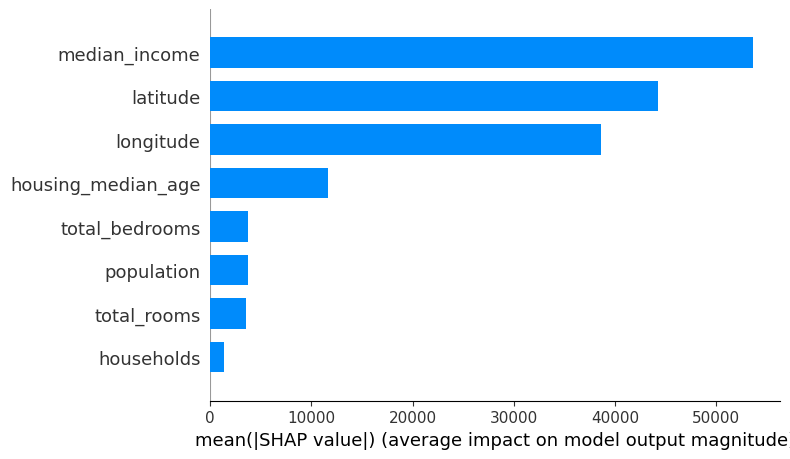

CPU times: user 1.03 s, sys: 7.77 ms, total: 1.04 s
Wall time: 1.07 s


In [21]:
%%time
shap_values_dt = shap.TreeExplainer(model_dt).shap_values(X_train)  # Calculation of SHAP values
shap.summary_plot(shap_values_dt, X_train, plot_type="bar")  # Building a SHAP summary graph

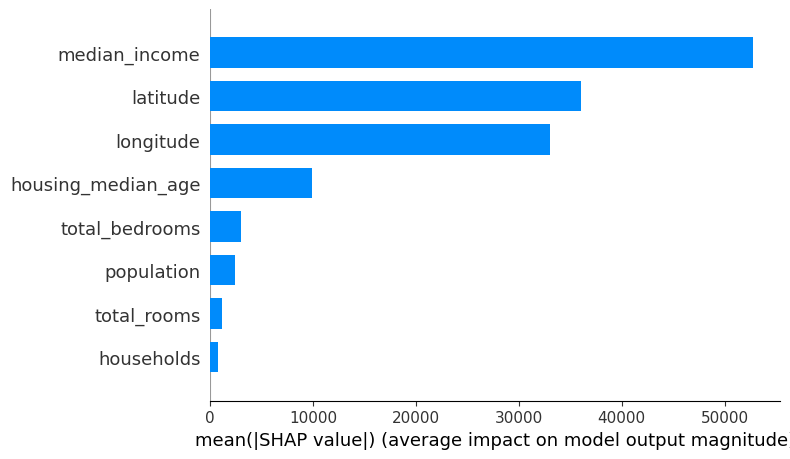

CPU times: user 10 s, sys: 89.4 ms, total: 10.1 s
Wall time: 10.3 s


In [22]:
%%time

# same for rnadom forest model
shap_values_rf = shap.TreeExplainer(model_rf).shap_values(X_train)
shap.summary_plot(shap_values_rf, X_train, plot_type="bar")

### shap.plots.bar

(Modern SHAP API) (recommended)

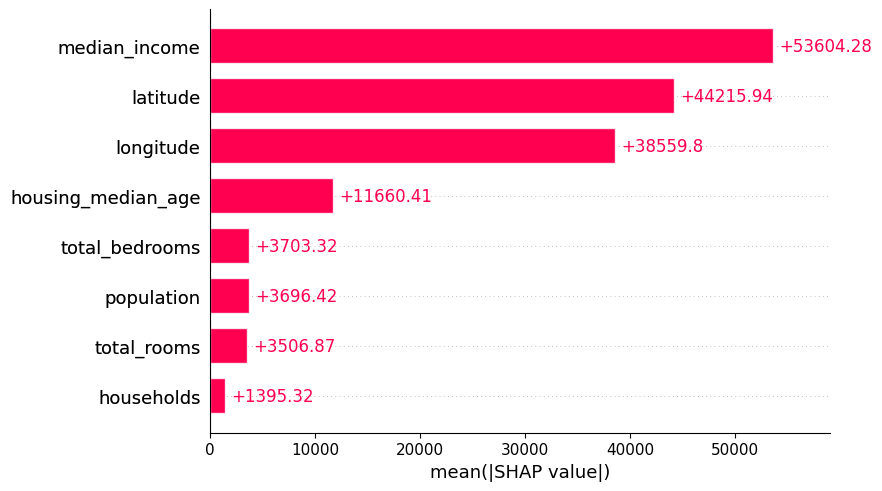

In [23]:
explainer = shap.TreeExplainer(model_dt)
shap_values_dt = explainer(X_train)
shap.plots.bar(shap_values_dt)

## SHAP Summary Plot

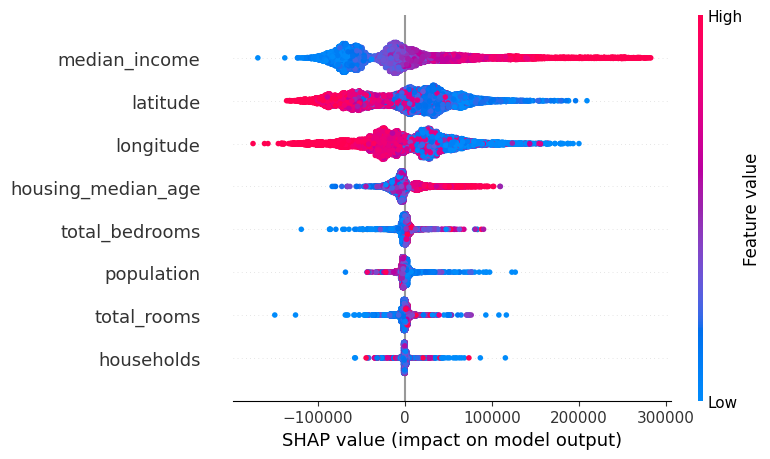

In [24]:
# Visualization of SHAP summary values ​​for the training dataset
shap.summary_plot(shap_values_dt, X_train)

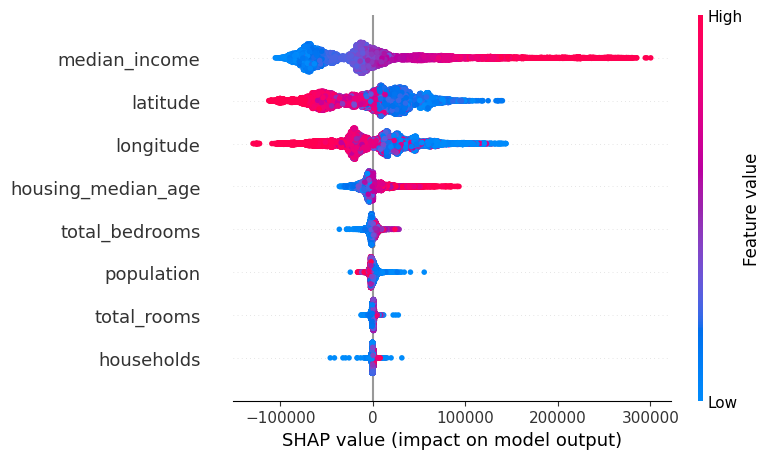

In [25]:
# same for random forest model
shap.summary_plot(shap_values_rf, X_train)

### shap.plots.beeswarm 

(Modern SHAP API) (recommended)

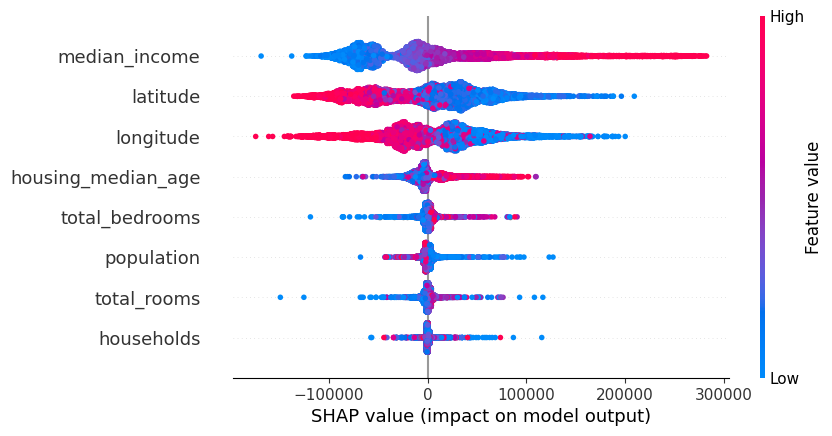

In [26]:
explainer = shap.TreeExplainer(model_dt)
shap_values_dt = explainer(X_train)
shap.plots.beeswarm(shap_values_dt)

## SHAP Dependence Plot

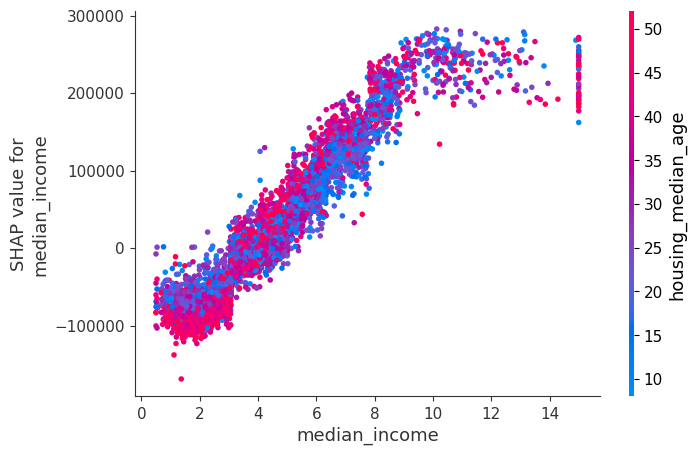

In [28]:
shap_values_dt = shap.TreeExplainer(model_dt).shap_values(X_train)
shap.dependence_plot('median_income', shap_values_dt, X_train) # interaction_index="housing_median_age" - if not provided it calculates automatically the feature with strongest interaction

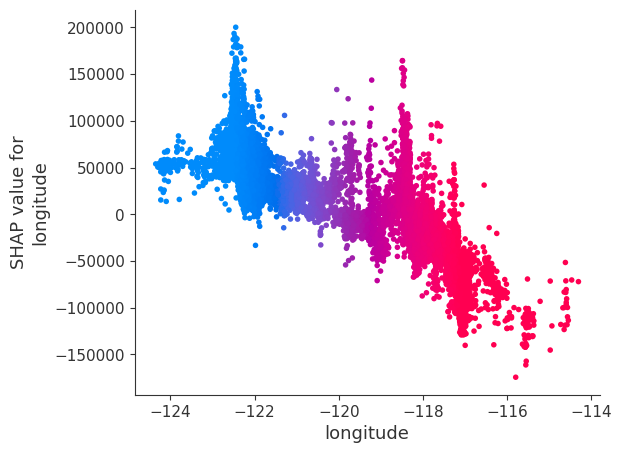

In [29]:
shap.dependence_plot('longitude', shap_values_dt, X_train, interaction_index="longitude")

### shap.plots.scatter

(Modern SHAP API) (recommended)

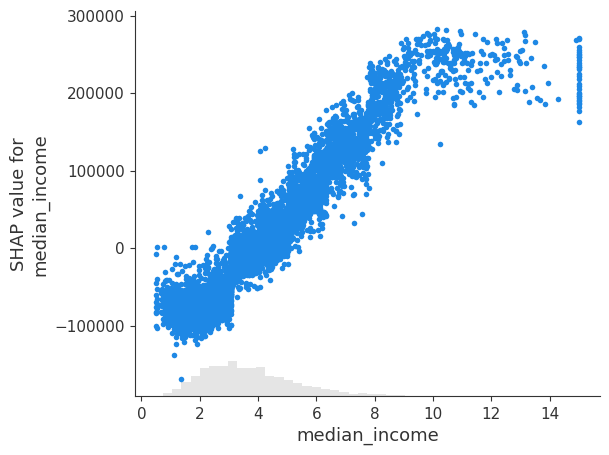

In [30]:
import shap

explainer = shap.TreeExplainer(model_dt)
shap_values_dt = explainer(X_train)
shap.plots.scatter(shap_values_dt[:, "median_income"])

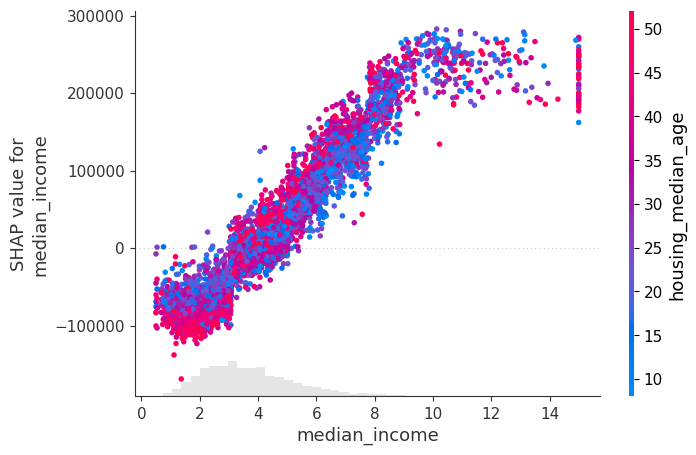

In [31]:
shap.plots.scatter(
    shap_values_dt[:, "median_income"],
    color=shap_values_dt # color=shap_values_dt[:, "housing_median_age"]
)

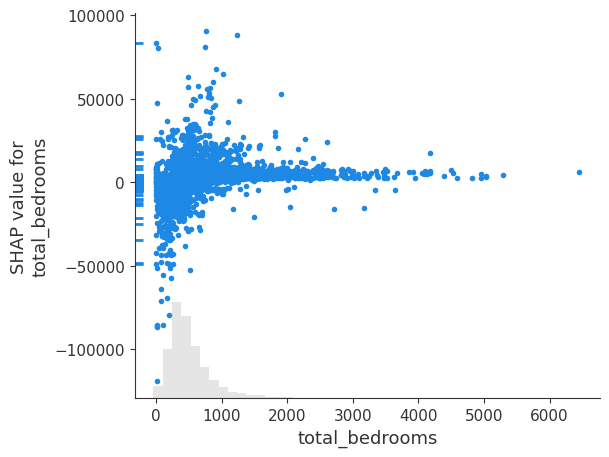

In [32]:
shap.plots.scatter(
    shap_values_dt[:, "total_bedrooms"]
)

## SHAP heatmap

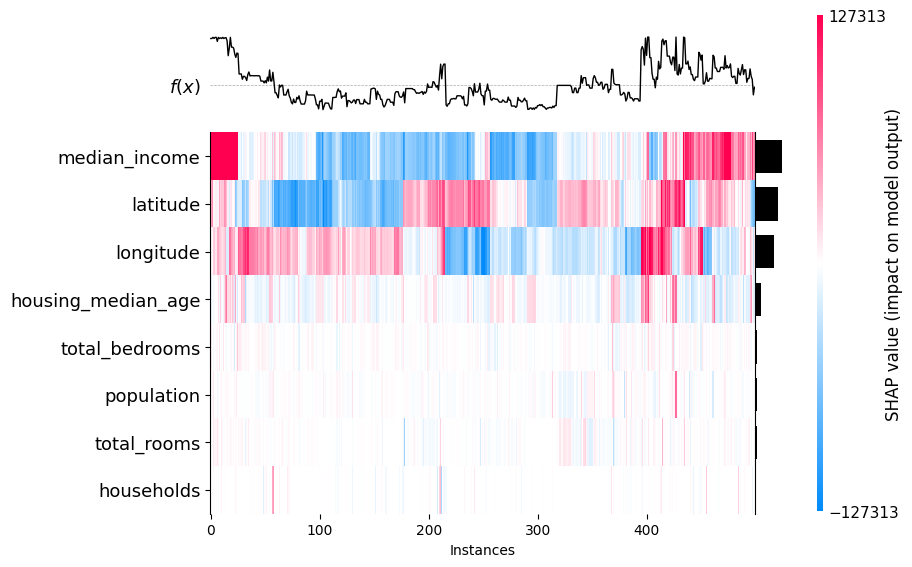

<Axes: xlabel='Instances'>

In [35]:
idx = np.random.choice(len(shap_values_dt), 500, replace=False)
shap.plots.heatmap(shap_values_dt[idx])